In [1]:
import torch
import sys

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is available: 1 device(s) detected.
Current device id: 0 - NVIDIA A100-SXM4-80GB


In [7]:
from main import load_and_process_config
from dataset import from_config
from utilities import tensor_dict_summarize

config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

DATASET  [13:35:54] Processing 1 datasets: ['STEREOMIS_TRACKING']

DATASET  [13:35:54] Using all scenes except VAL_SCENES for STEREOMIS_TRACKING training

DATASET  [13:35:54]   ✓ Created training dataset for STEREOMIS_TRACKING: 1200 samples (excluding 1 val scenes)

DATASET  [13:35:54]   ✓ Created validation dataset for STEREOMIS_TRACKING: 200 samples from 1 scenes

DATASET  [13:35:54] === Dataset Creation Summary ===

DATASET  [13:35:54] Training:   1200 total samples

DATASET  [13:35:54] Validation: 200 total samples

DATASET  [13:35:54] Test:       200 total samples

raw: shape=(1, 3, 448, 448), device=cuda:0

specular: shape=(1, 3, 448, 448), device=cuda:0

diffuse: shape=(1, 3, 448, 448), device=cuda:0

intrinsics: shape=(1, 3, 3), device=cuda:0

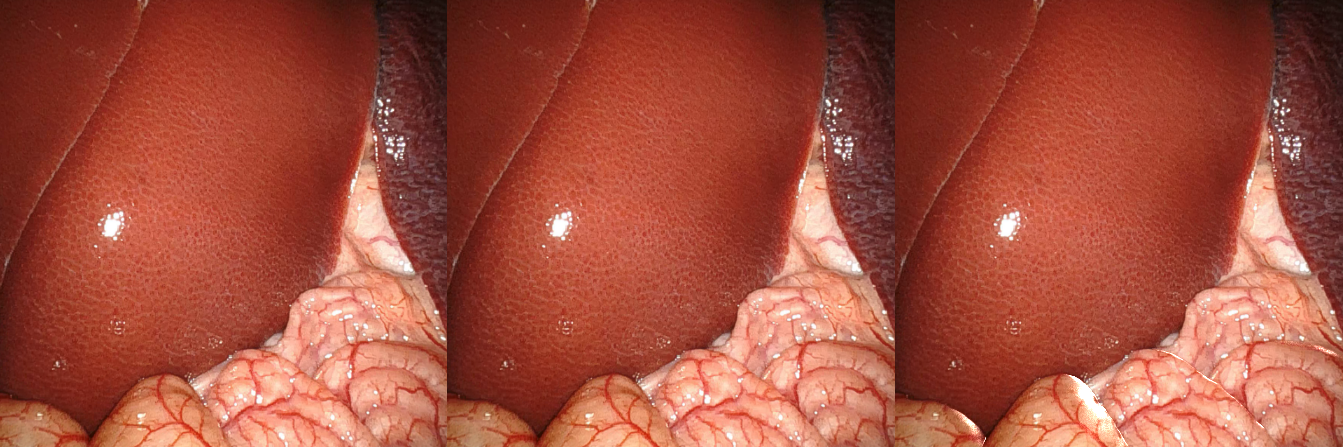

In [8]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
highlighter = PolarHighlighter(width=448, height=448).cuda()

for batch in dataloader:
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    tensor_dict_summarize(batch)
    highlighted = highlighter(
        batch["diffuse"],
        noise=0.03,
        noise_type=config.NOISE_TYPE,
        noise_octaves=config.NOISE_OCTAVES,
        noise_persistence=config.NOISE_PERSISTENCE,
        surface_roughness=config.SURFACE_ROUGHNESS,
        intensity=config.INTENSITY,
    )
    rgb(
        panelize(
            rgb(batch["raw"], as_tensor=True, resize=(448, 448)),
            rgb(batch["diffuse"], as_tensor=True, resize=(448, 448)),
            rgb(highlighted["rgb_highlighted"], as_tensor=True, resize=(448, 448)),
        )
    )
    break
